# 3.7 Dimension-Factor Correlation Analysis

This notebook identifies which latent dimensions are most strongly correlated with specific factors:
- **Age**: Continuous variable
- **Sex**: Binary variable (0=Female, 1=Male)
- **Handedness**: Categorical variable (1=Right, 2=Left)
- **Scanner**: Categorical variable (Manufacturer)
- **SBR**: Continuous variable (using SBR_PC1 as primary pathology measure)

## Objective
For each factor, identify:
1. The **single dimension** with the highest correlation
2. The **separation gap** between the top dimension and the 2nd-best dimension
3. Whether this top dimension is well-separated (indicating a clear signal)

## Methods
- **Pearson correlation**: For continuous variables (Age, SBR_PC1)
- **Point-biserial correlation**: For binary variables (Sex)
- **Eta-squared (η²)**: For categorical variables (Handedness, Scanner)
- **Separation metric**: Gap between 1st and 2nd ranked correlations

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

RANDOM_STATE = 42

print(f"Number of latent dimensions: {len(FEATURE_COLS)}")

Number of latent dimensions: 256


### 1.3 Load and Merge All Data

In [3]:
df_combined = pd.read_csv('output/final_train_combined_vae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

Combined dataset shape: (2373, 303)
Unique patients in combined data: 1437

Visits per patient statistics:
count    1437.000000
mean        1.651357
std         0.955241
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
Patients with multiple visits: 553


### 1.4 Calculate SBR Principal Components

In [5]:
# Filter to rows with complete SBR data
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
print(f"Rows with complete SBR data: {len(df_with_sbr)}")

# Standardize and apply PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=RANDOM_STATE)
sbr_pcs = pca.fit_transform(sbr_scaled)

df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]

print(f"\nSBR PCA explained variance: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

# Use this as final dataset
df_final = df_with_sbr.reset_index(drop=True)
print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Rows with complete SBR data: 2373

SBR PCA explained variance: [0.88338287 0.05277345 0.04814441]
Total variance explained: 98.43%

Final dataset: (2373, 306)
Unique patients: 1437


### 1.5 Check Available Factors

In [6]:
print("Factor Availability Check:")
print("="*80)

# Age
age_available = df_final['AGE_AT_VISIT'].notna().sum()
print(f"\nAge (AGE_AT_VISIT):")
print(f"  Available: {age_available}/{len(df_final)} ({age_available/len(df_final)*100:.1f}%)")
if age_available > 0:
    print(f"  Range: [{df_final['AGE_AT_VISIT'].min():.0f}, {df_final['AGE_AT_VISIT'].max():.0f}]")
    print(f"  Mean: {df_final['AGE_AT_VISIT'].mean():.1f}")

# Sex
sex_available = df_final['SEX'].notna().sum()
print(f"\nSex:")
print(f"  Available: {sex_available}/{len(df_final)} ({sex_available/len(df_final)*100:.1f}%)")
if sex_available > 0:
    print(f"  Distribution:\n{df_final['SEX'].value_counts()}")

# Handedness
handed_available = df_final['HANDED'].notna().sum()
print(f"\nHandedness:")
print(f"  Available: {handed_available}/{len(df_final)} ({handed_available/len(df_final)*100:.1f}%)")
if handed_available > 0:
    print(f"  Distribution:\n{df_final['HANDED'].value_counts()}")


# Scanner
scanner_available = df_final['Manufacturer'].notna().sum()
print(f"\nScanner (Manufacturer):")
print(f"  Available: {scanner_available}/{len(df_final)} ({scanner_available/len(df_final)*100:.1f}%)")
if scanner_available > 0:
    print(f"  Unique manufacturers: {df_final['Manufacturer'].nunique()}")
    print(f"  Top 5:\n{df_final['Manufacturer'].value_counts().head()}")

# SBR
sbr_available = df_final['SBR_PC1'].notna().sum()
print(f"\nSBR (SBR_PC1):")
print(f"  Available: {sbr_available}/{len(df_final)} ({sbr_available/len(df_final)*100:.1f}%)")
if sbr_available > 0:
    print(f"  Range: [{df_final['SBR_PC1'].min():.2f}, {df_final['SBR_PC1'].max():.2f}]")
    print(f"  Mean: {df_final['SBR_PC1'].mean():.2f}")

Factor Availability Check:

Age (AGE_AT_VISIT):
  Available: 2371/2373 (99.9%)
  Range: [29, 89]
  Mean: 63.4

Sex:
  Available: 2371/2373 (99.9%)
  Distribution:
SEX
1.0    1483
0.0     888
Name: count, dtype: int64

Handedness:
  Available: 2370/2373 (99.9%)
  Distribution:
HANDED
1.0    2055
2.0     241
3.0      74
Name: count, dtype: int64

Scanner (Manufacturer):
  Available: 2372/2373 (100.0%)
  Unique manufacturers: 16
  Top 5:
Manufacturer
SIEMENS NM                              1173
GE MEDICAL SYSTEMS                       470
Marconi Medical Systems, NM Division     258
PICKER                                   130
Philips Nuclear Medicine                 101
Name: count, dtype: int64

SBR (SBR_PC1):
  Available: 2373/2373 (100.0%)
  Range: [-4.52, 11.08]
  Mean: -0.00


## Section 2: Correlation Analysis Functions

### 2.1 Define Correlation Functions

In [7]:
def compute_continuous_correlations(X, y, feature_names):
    """
    Compute Pearson correlations between features (X) and continuous target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = stats.pearsonr(X[mask, i], y[mask])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_binary_correlations(X, y, feature_names):
    """
    Compute point-biserial correlations between features (X) and binary target (y).
    Returns DataFrame with correlations, p-values, and absolute correlations.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | np.isnan(y))
        if mask.sum() < 3:
            continue
            
        r, p = pointbiserialr(y[mask], X[mask, i])
        results.append({
            'Feature': feature,
            'Correlation': r,
            'P_Value': p,
            'Abs_Correlation': abs(r)
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


def compute_categorical_associations(X, y, feature_names):
    """
    Compute eta-squared (η²) for association between features (X) and categorical target (y).
    η² represents the proportion of variance in the feature explained by the category.
    Returns DataFrame with eta-squared values.
    """
    results = []
    
    for i, feature in enumerate(feature_names):
        # Remove NaN pairs
        mask = ~(np.isnan(X[:, i]) | pd.isna(y))
        if mask.sum() < 3:
            continue
        
        x_clean = X[mask, i]
        y_clean = y[mask]
        
        # Get unique categories
        categories = np.unique(y_clean)
        if len(categories) < 2:
            continue
        
        # Compute ANOVA
        groups = [x_clean[y_clean == cat] for cat in categories]
        f_stat, p_val = stats.f_oneway(*groups)
        
        # Compute eta-squared
        grand_mean = x_clean.mean()
        ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
        ss_total = sum((x_clean - grand_mean)**2)
        eta_squared = ss_between / ss_total if ss_total > 0 else 0
        
        results.append({
            'Feature': feature,
            'Eta_Squared': eta_squared,
            'F_Statistic': f_stat,
            'P_Value': p_val
        })
    
    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('Eta_Squared', ascending=False).reset_index(drop=True)
    df_results['Rank'] = range(1, len(df_results) + 1)
    
    return df_results


print("Correlation functions defined successfully!")

Correlation functions defined successfully!


### 2.2 Define Separation Analysis Function

In [8]:
def analyze_separation(df_corr, metric_col='Abs_Correlation', top_n=10):
    """
    Analyze separation between top-ranked features.
    Returns summary statistics and separation gap.
    """
    if len(df_corr) < 2:
        return None
    
    top_feature = df_corr.iloc[0]
    second_feature = df_corr.iloc[1]
    
    gap = top_feature[metric_col] - second_feature[metric_col]
    gap_pct = (gap / top_feature[metric_col] * 100) if top_feature[metric_col] > 0 else 0
    
    summary = {
        'Top_Feature': top_feature['Feature'],
        'Top_Value': top_feature[metric_col],
        'Second_Feature': second_feature['Feature'],
        'Second_Value': second_feature[metric_col],
        'Gap': gap,
        'Gap_Percent': gap_pct,
        'Top_N_Features': df_corr.head(top_n)['Feature'].tolist(),
        'Top_N_Values': df_corr.head(top_n)[metric_col].tolist()
    }
    
    return summary


print("Separation analysis function defined!")

Separation analysis function defined!


## Section 3: Factor-by-Factor Analysis

### 3.1 Extract Latent Features

In [9]:
# Extract latent features matrix
X_latent = df_final[FEATURE_COLS].values
print(f"Latent features matrix shape: {X_latent.shape}")
print(f"Missing values: {np.isnan(X_latent).sum()}")

Latent features matrix shape: (2373, 256)
Missing values: 0


### 3.2 Age Analysis

In [9]:
print("="*80)
print("FACTOR 1: AGE")
print("="*80)

y_age = df_final['AGE_AT_VISIT'].values
print(f"\nSamples with valid age: {(~np.isnan(y_age)).sum()}")

# Compute correlations
df_age_corr = compute_continuous_correlations(X_latent, y_age, FEATURE_COLS)

# Analyze separation
age_sep = analyze_separation(df_age_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {age_sep['Top_Feature']}")
print(f"  Correlation: {age_sep['Top_Value']:.4f}")
print(f"  P-value: {df_age_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {age_sep['Second_Feature']}")
print(f"  Correlation: {age_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {age_sep['Gap']:.4f}")
print(f"  Relative: {age_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_age_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))

FACTOR 1: AGE

Samples with valid age: 2368

Top dimension: latent_75
  Correlation: 0.0579
  P-value: 4.8295e-03

Second-best dimension: latent_122
  Correlation: 0.0457

Separation Gap:
  Absolute: 0.0122
  Relative: 21.1%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation  P_Value
    1  latent_75     0.057896         0.057896 0.004829
    2 latent_122     0.045702         0.045702 0.026151
    3   latent_9     0.043253         0.043253 0.035319
    4  latent_15    -0.043234         0.043234 0.035402
    5 latent_255     0.042837         0.042837 0.037125
    6  latent_71     0.041604         0.041604 0.042936
    7 latent_198     0.041104         0.041104 0.045500
    8 latent_200     0.040428         0.040428 0.049176
    9 latent_131    -0.039955         0.039955 0.051889
   10 latent_228    -0.039846         0.039846 0.052532


### 3.3 Sex Analysis

In [10]:
print("\n" + "="*80)
print("FACTOR 2: SEX")
print("="*80)

y_sex = df_final['SEX'].values
print(f"\nSamples with valid sex: {(~np.isnan(y_sex)).sum()}")
print(f"Distribution: Female={(y_sex==0).sum()}, Male={(y_sex==1).sum()}")

# Compute correlations
df_sex_corr = compute_binary_correlations(X_latent, y_sex, FEATURE_COLS)

# Analyze separation
sex_sep = analyze_separation(df_sex_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sex_sep['Top_Feature']}")
print(f"  Correlation: {sex_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sex_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sex_sep['Second_Feature']}")
print(f"  Correlation: {sex_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sex_sep['Gap']:.4f}")
print(f"  Relative: {sex_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sex_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 2: SEX

Samples with valid sex: 2368
Distribution: Female=855, Male=1513

Top dimension: latent_148
  Correlation: 0.0593
  P-value: 3.9150e-03

Second-best dimension: latent_94
  Correlation: 0.0569

Separation Gap:
  Absolute: 0.0024
  Relative: 4.0%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation  P_Value
    1 latent_148     0.059264         0.059264 0.003915
    2  latent_94    -0.056891         0.056891 0.005619
    3  latent_10    -0.044173         0.044173 0.031596
    4 latent_220    -0.043730         0.043730 0.033345
    5 latent_157    -0.043259         0.043259 0.035294
    6 latent_136     0.042015         0.042015 0.040916
    7  latent_80    -0.040740         0.040740 0.047451
    8  latent_63    -0.039991         0.039991 0.051680
    9 latent_253    -0.039889         0.039889 0.052279
   10 latent_137    -0.039499         0.039499 0.054624


### 3.4 Handedness Analysis

In [11]:
print("\n" + "="*80)
print("FACTOR 3: HANDEDNESS")
print("="*80)

y_hand = df_final["HANDED"].values
valid_hand = pd.notna(y_hand)
print(f"\nSamples with valid handedness: {valid_hand.sum()}")

if valid_hand.sum() > 0:
    print(f"Distribution:\n{pd.Series(y_hand).value_counts()}")
    
    # Categorical - use eta-squared
    print("\nTreating as categorical variable...")
    df_hand_corr = compute_categorical_associations(X_latent, y_hand, FEATURE_COLS)
    metric_col = 'Eta_Squared'
    
    # Analyze separation
    hand_sep = analyze_separation(df_hand_corr, metric_col=metric_col, top_n=10)
    
    print(f"\nTop dimension: {hand_sep['Top_Feature']}")
    print(f"  {metric_col}: {hand_sep['Top_Value']:.4f}")
    print(f"  P-value: {df_hand_corr.iloc[0]['P_Value']:.4e}")
    
    print(f"\nSecond-best dimension: {hand_sep['Second_Feature']}")
    print(f"  {metric_col}: {hand_sep['Second_Value']:.4f}")
    
    print(f"\nSeparation Gap:")
    print(f"  Absolute: {hand_sep['Gap']:.4f}")
    print(f"  Relative: {hand_sep['Gap_Percent']:.1f}%")
    
    print(f"\nTop 10 dimensions:")
    print(df_hand_corr.head(10).to_string(index=False))


FACTOR 3: HANDEDNESS

Samples with valid handedness: 2367
Distribution:
1.0    2074
2.0     222
3.0      71
Name: count, dtype: int64

Treating as categorical variable...

Top dimension: latent_140
  Eta_Squared: 0.0035
  P-value: 1.5557e-02

Second-best dimension: latent_184
  Eta_Squared: 0.0035

Separation Gap:
  Absolute: 0.0000
  Relative: 0.9%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic  P_Value  Rank
latent_140     0.003516     4.170606 0.015557     1
latent_184     0.003484     4.132070 0.016166     2
latent_151     0.003483     4.131408 0.016176     3
 latent_46     0.003441     4.081550 0.017000     4
latent_145     0.003390     4.020236 0.018072     5
latent_179     0.003335     3.955329 0.019279     6
latent_172     0.003332     3.952137 0.019341     7
 latent_98     0.003144     3.727718 0.024189     8
 latent_91     0.003101     3.676744 0.025450     9
 latent_10     0.003096     3.670450 0.025610    10


### 3.5 Scanner Analysis

In [12]:
print("\n" + "="*80)
print("FACTOR 4: SCANNER (Manufacturer)")
print("="*80)

y_scanner = df_final['Manufacturer'].values
valid_scanner = pd.notna(y_scanner)
print(f"\nSamples with valid scanner: {valid_scanner.sum()}")
print(f"Unique manufacturers: {pd.Series(y_scanner).nunique()}")
print(f"\nTop 5 manufacturers:\n{pd.Series(y_scanner).value_counts().head()}")

# Compute eta-squared
df_scanner_corr = compute_categorical_associations(X_latent, y_scanner, FEATURE_COLS)

# Analyze separation
scanner_sep = analyze_separation(df_scanner_corr, metric_col='Eta_Squared', top_n=10)

print(f"\nTop dimension: {scanner_sep['Top_Feature']}")
print(f"  Eta-squared: {scanner_sep['Top_Value']:.4f}")
print(f"  P-value: {df_scanner_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {scanner_sep['Second_Feature']}")
print(f"  Eta-squared: {scanner_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {scanner_sep['Gap']:.4f}")
print(f"  Relative: {scanner_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_scanner_corr.head(10).to_string(index=False))


FACTOR 4: SCANNER (Manufacturer)

Samples with valid scanner: 2369
Unique manufacturers: 16

Top 5 manufacturers:
SIEMENS NM                              1266
GE MEDICAL SYSTEMS                       458
Marconi Medical Systems, NM Division     182
PICKER                                   147
Philips Nuclear Medicine                 110
Name: count, dtype: int64

Top dimension: latent_127
  Eta-squared: 0.0120
  P-value: 1.9258e-02

Second-best dimension: latent_25
  Eta-squared: 0.0117

Separation Gap:
  Absolute: 0.0002
  Relative: 1.9%

Top 10 dimensions:
   Feature  Eta_Squared  F_Statistic  P_Value  Rank
latent_127     0.011960     1.898788 0.019258     1
 latent_25     0.011733     1.862288 0.022551     2
latent_240     0.011718     1.860010 0.022772     3
 latent_33     0.011457     1.818068 0.027234     4
 latent_44     0.011438     1.814958 0.027595     5
 latent_60     0.011427     1.813302 0.027789     6
latent_207     0.010749     1.704490 0.043623     7
 latent_39     0.0

### 3.6 SBR Analysis

In [13]:
print("\n" + "="*80)
print("FACTOR 5: SBR (SBR_PC1)")
print("="*80)

y_sbr = df_final['SBR_PC1'].values
print(f"\nSamples with valid SBR: {(~np.isnan(y_sbr)).sum()}")
print(f"SBR_PC1 range: [{np.nanmin(y_sbr):.2f}, {np.nanmax(y_sbr):.2f}]")
print(f"SBR_PC1 mean: {np.nanmean(y_sbr):.2f}")

# Compute correlations
df_sbr_corr = compute_continuous_correlations(X_latent, y_sbr, FEATURE_COLS)

# Analyze separation
sbr_sep = analyze_separation(df_sbr_corr, metric_col='Abs_Correlation', top_n=10)

print(f"\nTop dimension: {sbr_sep['Top_Feature']}")
print(f"  Correlation: {sbr_sep['Top_Value']:.4f}")
print(f"  P-value: {df_sbr_corr.iloc[0]['P_Value']:.4e}")

print(f"\nSecond-best dimension: {sbr_sep['Second_Feature']}")
print(f"  Correlation: {sbr_sep['Second_Value']:.4f}")

print(f"\nSeparation Gap:")
print(f"  Absolute: {sbr_sep['Gap']:.4f}")
print(f"  Relative: {sbr_sep['Gap_Percent']:.1f}%")

print(f"\nTop 10 dimensions:")
print(df_sbr_corr.head(10)[['Rank', 'Feature', 'Correlation', 'Abs_Correlation', 'P_Value']].to_string(index=False))


FACTOR 5: SBR (SBR_PC1)

Samples with valid SBR: 2370
SBR_PC1 range: [-4.58, 11.14]
SBR_PC1 mean: 0.00

Top dimension: latent_243
  Correlation: 0.0559
  P-value: 6.4501e-03

Second-best dimension: latent_178
  Correlation: 0.0534

Separation Gap:
  Absolute: 0.0026
  Relative: 4.6%

Top 10 dimensions:
 Rank    Feature  Correlation  Abs_Correlation  P_Value
    1 latent_243    -0.055939         0.055939 0.006450
    2 latent_178     0.053352         0.053352 0.009382
    3 latent_199     0.050234         0.050234 0.014454
    4 latent_201    -0.047318         0.047318 0.021242
    5 latent_198    -0.045771         0.045771 0.025865
    6 latent_176     0.045497         0.045497 0.026767
    7 latent_238    -0.045416         0.045416 0.027039
    8  latent_59     0.044422         0.044422 0.030581
    9 latent_239     0.042846         0.042846 0.037005
   10 latent_101    -0.042577         0.042577 0.038209


## Section 4: Summary and Visualization

### 4.1 Create Summary Table

In [14]:
print("\n" + "="*80)
print("SUMMARY: TOP DIMENSION FOR EACH FACTOR")
print("="*80)

summary_data = []

# Age
summary_data.append({
    'Factor': 'Age',
    'Top_Dimension': age_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': age_sep['Top_Value'],
    'Second_Value': age_sep['Second_Value'],
    'Gap': age_sep['Gap'],
    'Gap_Percent': age_sep['Gap_Percent'],
    'P_Value': df_age_corr.iloc[0]['P_Value']
})

# Sex
summary_data.append({
    'Factor': 'Sex',
    'Top_Dimension': sex_sep['Top_Feature'],
    'Metric': 'Point-biserial r',
    'Top_Value': sex_sep['Top_Value'],
    'Second_Value': sex_sep['Second_Value'],
    'Gap': sex_sep['Gap'],
    'Gap_Percent': sex_sep['Gap_Percent'],
    'P_Value': df_sex_corr.iloc[0]['P_Value']
})

# Handedness (if available)
if hand_sep is not None:
    metric_name = 'Eta²' if 'Eta_Squared' in df_hand_corr.columns else 'Point-biserial r'
    summary_data.append({
        'Factor': 'Handedness',
        'Top_Dimension': hand_sep['Top_Feature'],
        'Metric': metric_name,
        'Top_Value': hand_sep['Top_Value'],
        'Second_Value': hand_sep['Second_Value'],
        'Gap': hand_sep['Gap'],
        'Gap_Percent': hand_sep['Gap_Percent'],
        'P_Value': df_hand_corr.iloc[0]['P_Value']
    })

# Scanner
summary_data.append({
    'Factor': 'Scanner',
    'Top_Dimension': scanner_sep['Top_Feature'],
    'Metric': 'Eta²',
    'Top_Value': scanner_sep['Top_Value'],
    'Second_Value': scanner_sep['Second_Value'],
    'Gap': scanner_sep['Gap'],
    'Gap_Percent': scanner_sep['Gap_Percent'],
    'P_Value': df_scanner_corr.iloc[0]['P_Value']
})

# SBR
summary_data.append({
    'Factor': 'SBR',
    'Top_Dimension': sbr_sep['Top_Feature'],
    'Metric': 'Pearson r',
    'Top_Value': sbr_sep['Top_Value'],
    'Second_Value': sbr_sep['Second_Value'],
    'Gap': sbr_sep['Gap'],
    'Gap_Percent': sbr_sep['Gap_Percent'],
    'P_Value': df_sbr_corr.iloc[0]['P_Value']
})

df_summary = pd.DataFrame(summary_data)
print("\n", df_summary.to_string(index=False))

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("\nSeparation Quality:")
for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    print(f"  {row['Factor']}: {quality} separation ({row['Gap_Percent']:.1f}% gap)")


SUMMARY: TOP DIMENSION FOR EACH FACTOR

     Factor Top_Dimension           Metric  Top_Value  Second_Value      Gap  Gap_Percent  P_Value
       Age     latent_75        Pearson r   0.057896      0.045702 0.012193    21.060703 0.004829
       Sex    latent_148 Point-biserial r   0.059264      0.056891 0.002373     4.003931 0.003915
Handedness    latent_140             Eta²   0.003516      0.003484 0.000032     0.920751 0.015557
   Scanner    latent_127             Eta²   0.011960      0.011733 0.000227     1.899695 0.019258
       SBR    latent_243        Pearson r   0.055939      0.053352 0.002588     4.625551 0.006450

INTERPRETATION

Separation Quality:
  Age: EXCELLENT separation (21.1% gap)
  Sex: WEAK separation (4.0% gap)
  Handedness: WEAK separation (0.9% gap)
  Scanner: WEAK separation (1.9% gap)
  SBR: WEAK separation (4.6% gap)


### 4.2 Visualization: Top Dimensions and Separation Gaps

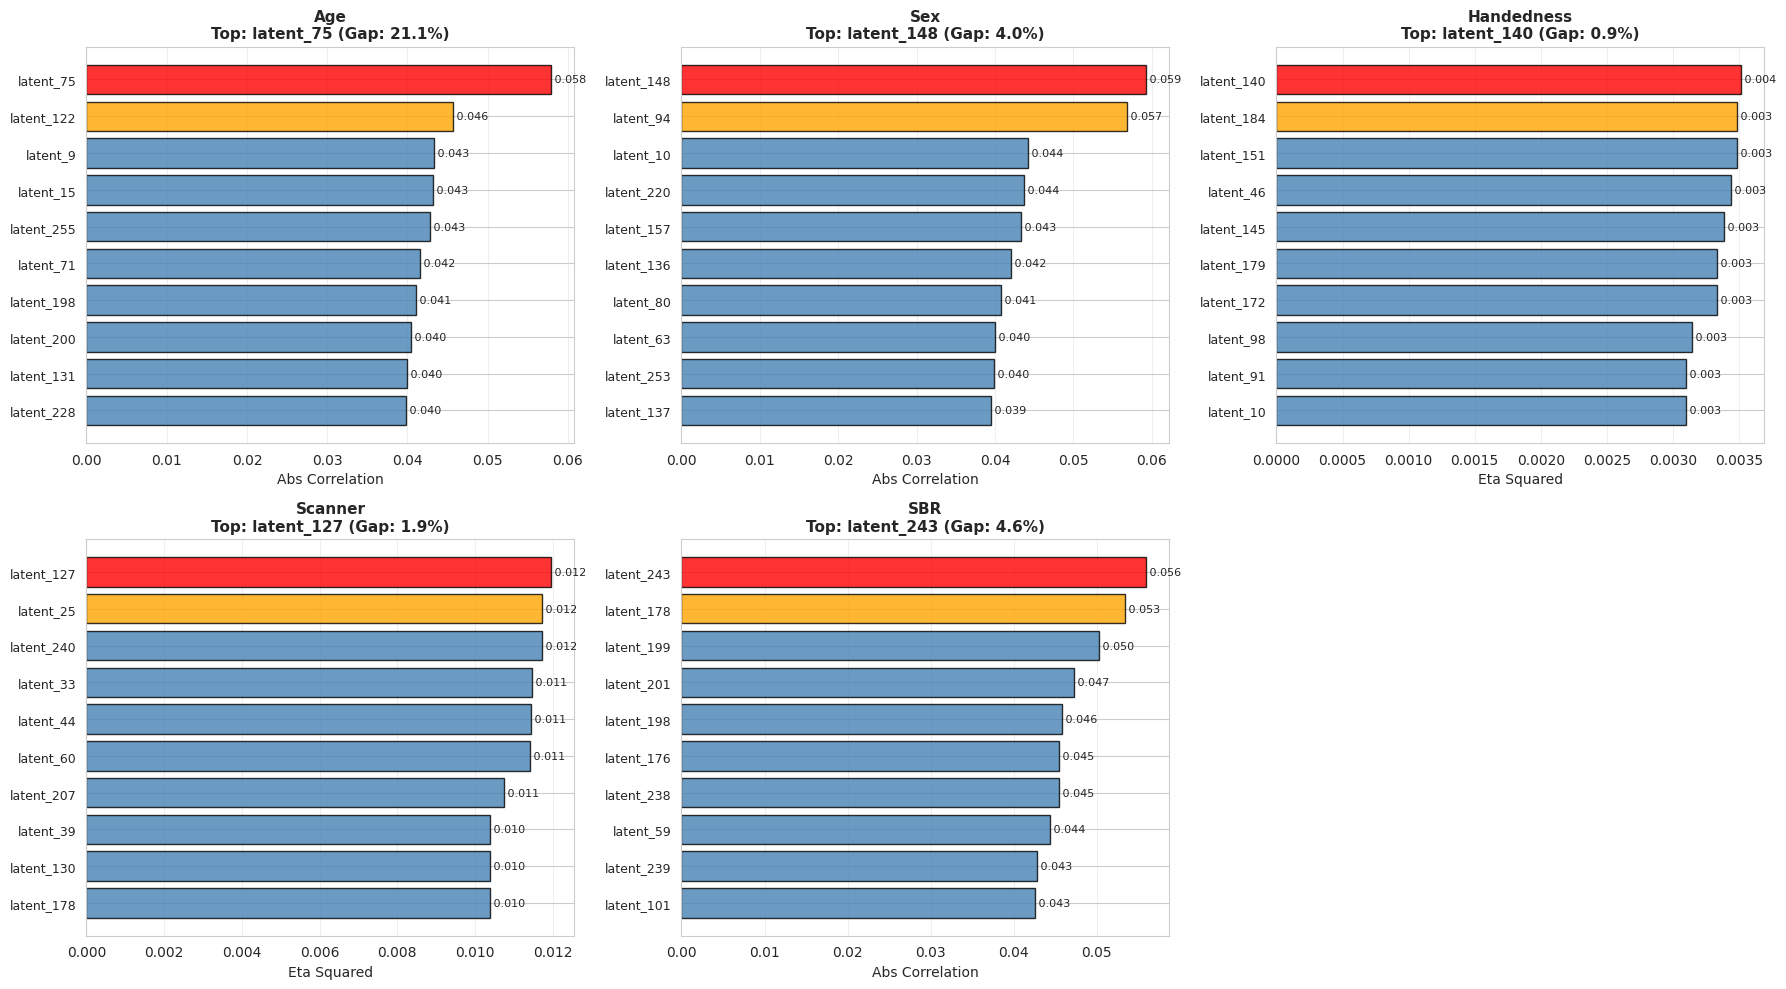

Plot saved to: output/dimension_factor_correlation_top10.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Plot for each factor
plot_data = [
    ('Age', df_age_corr, age_sep, 'Abs_Correlation'),
    ('Sex', df_sex_corr, sex_sep, 'Abs_Correlation'),
    ('Handedness', df_hand_corr, hand_sep, 'Eta_Squared' if df_hand_corr is not None and 'Eta_Squared' in df_hand_corr.columns else 'Abs_Correlation'),
    ('Scanner', df_scanner_corr, scanner_sep, 'Eta_Squared'),
    ('SBR', df_sbr_corr, sbr_sep, 'Abs_Correlation')
]

for idx, (factor_name, df_corr, sep, metric_col) in enumerate(plot_data):
    if df_corr is None or sep is None:
        axes[idx].text(0.5, 0.5, f'{factor_name}\nNo data available', 
                      ha='center', va='center', fontsize=12)
        axes[idx].set_xticks([])
        axes[idx].set_yticks([])
        continue
    
    # Get top 10
    top_10 = df_corr.head(10)
    
    # Create bar plot
    colors = ['red' if i == 0 else 'orange' if i == 1 else 'steelblue' for i in range(len(top_10))]
    bars = axes[idx].barh(range(len(top_10)), top_10[metric_col], color=colors, edgecolor='black', alpha=0.8)
    
    axes[idx].set_yticks(range(len(top_10)))
    axes[idx].set_yticklabels(top_10['Feature'], fontsize=9)
    axes[idx].set_xlabel(metric_col.replace('_', ' '), fontsize=10)
    axes[idx].set_title(f'{factor_name}\nTop: {sep["Top_Feature"]} (Gap: {sep["Gap_Percent"]:.1f}%)', 
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()
    
    # Add value labels
    for i, (feat, val) in enumerate(zip(top_10['Feature'], top_10[metric_col])):
        axes[idx].text(val, i, f' {val:.3f}', va='center', fontsize=8)

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('output/dimension_factor_correlation_top10.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_correlation_top10.png")

### 4.3 Visualization: Separation Gap Comparison

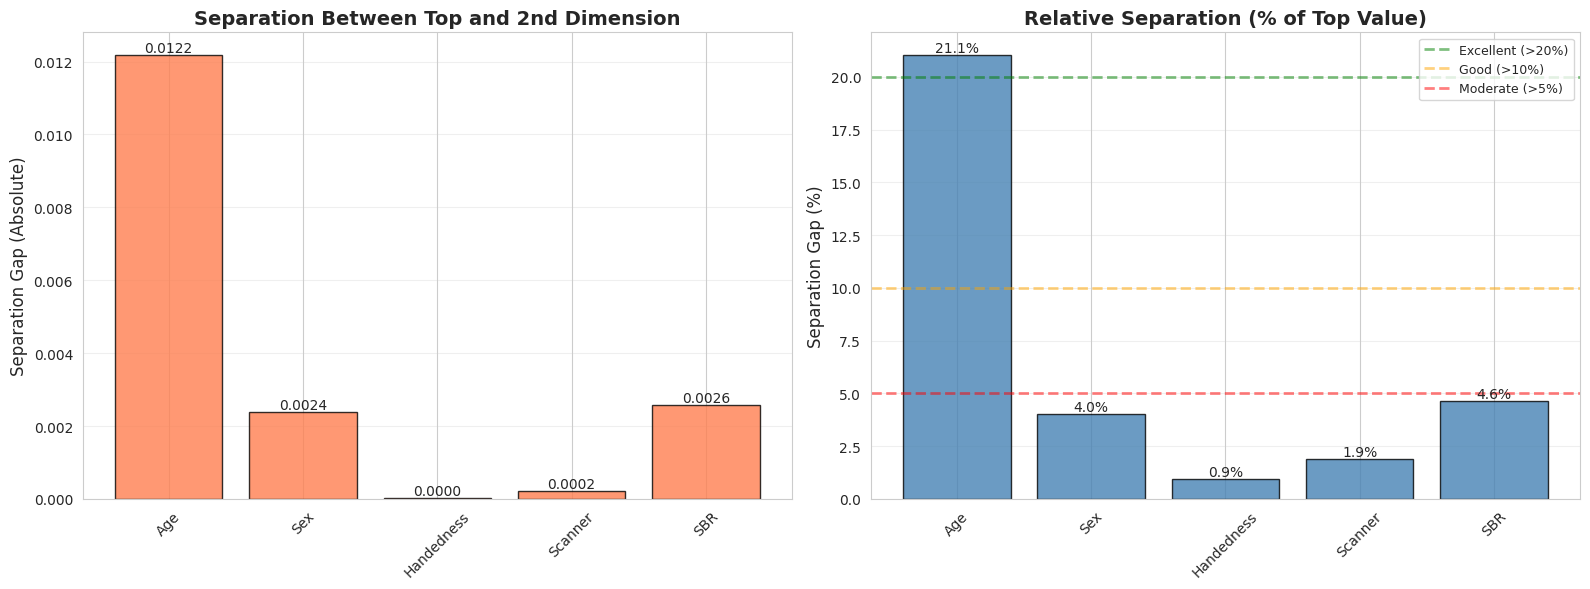

Plot saved to: output/dimension_factor_separation_gaps.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Absolute gap
axes[0].bar(df_summary['Factor'], df_summary['Gap'], color='coral', edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Separation Gap (Absolute)', fontsize=12)
axes[0].set_title('Separation Between Top and 2nd Dimension', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Add value labels
for i, (factor, gap) in enumerate(zip(df_summary['Factor'], df_summary['Gap'])):
    axes[0].text(i, gap, f'{gap:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 2: Relative gap (percentage)
axes[1].bar(df_summary['Factor'], df_summary['Gap_Percent'], color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Separation Gap (%)', fontsize=12)
axes[1].set_title('Relative Separation (% of Top Value)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels
for i, (factor, gap_pct) in enumerate(zip(df_summary['Factor'], df_summary['Gap_Percent'])):
    axes[1].text(i, gap_pct, f'{gap_pct:.1f}%', ha='center', va='bottom', fontsize=10)

# Add threshold lines
axes[1].axhline(y=20, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Excellent (>20%)')
axes[1].axhline(y=10, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Good (>10%)')
axes[1].axhline(y=5, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Moderate (>5%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('output/dimension_factor_separation_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_separation_gaps.png")

### 4.4 Visualization: Heatmap of Top Dimensions

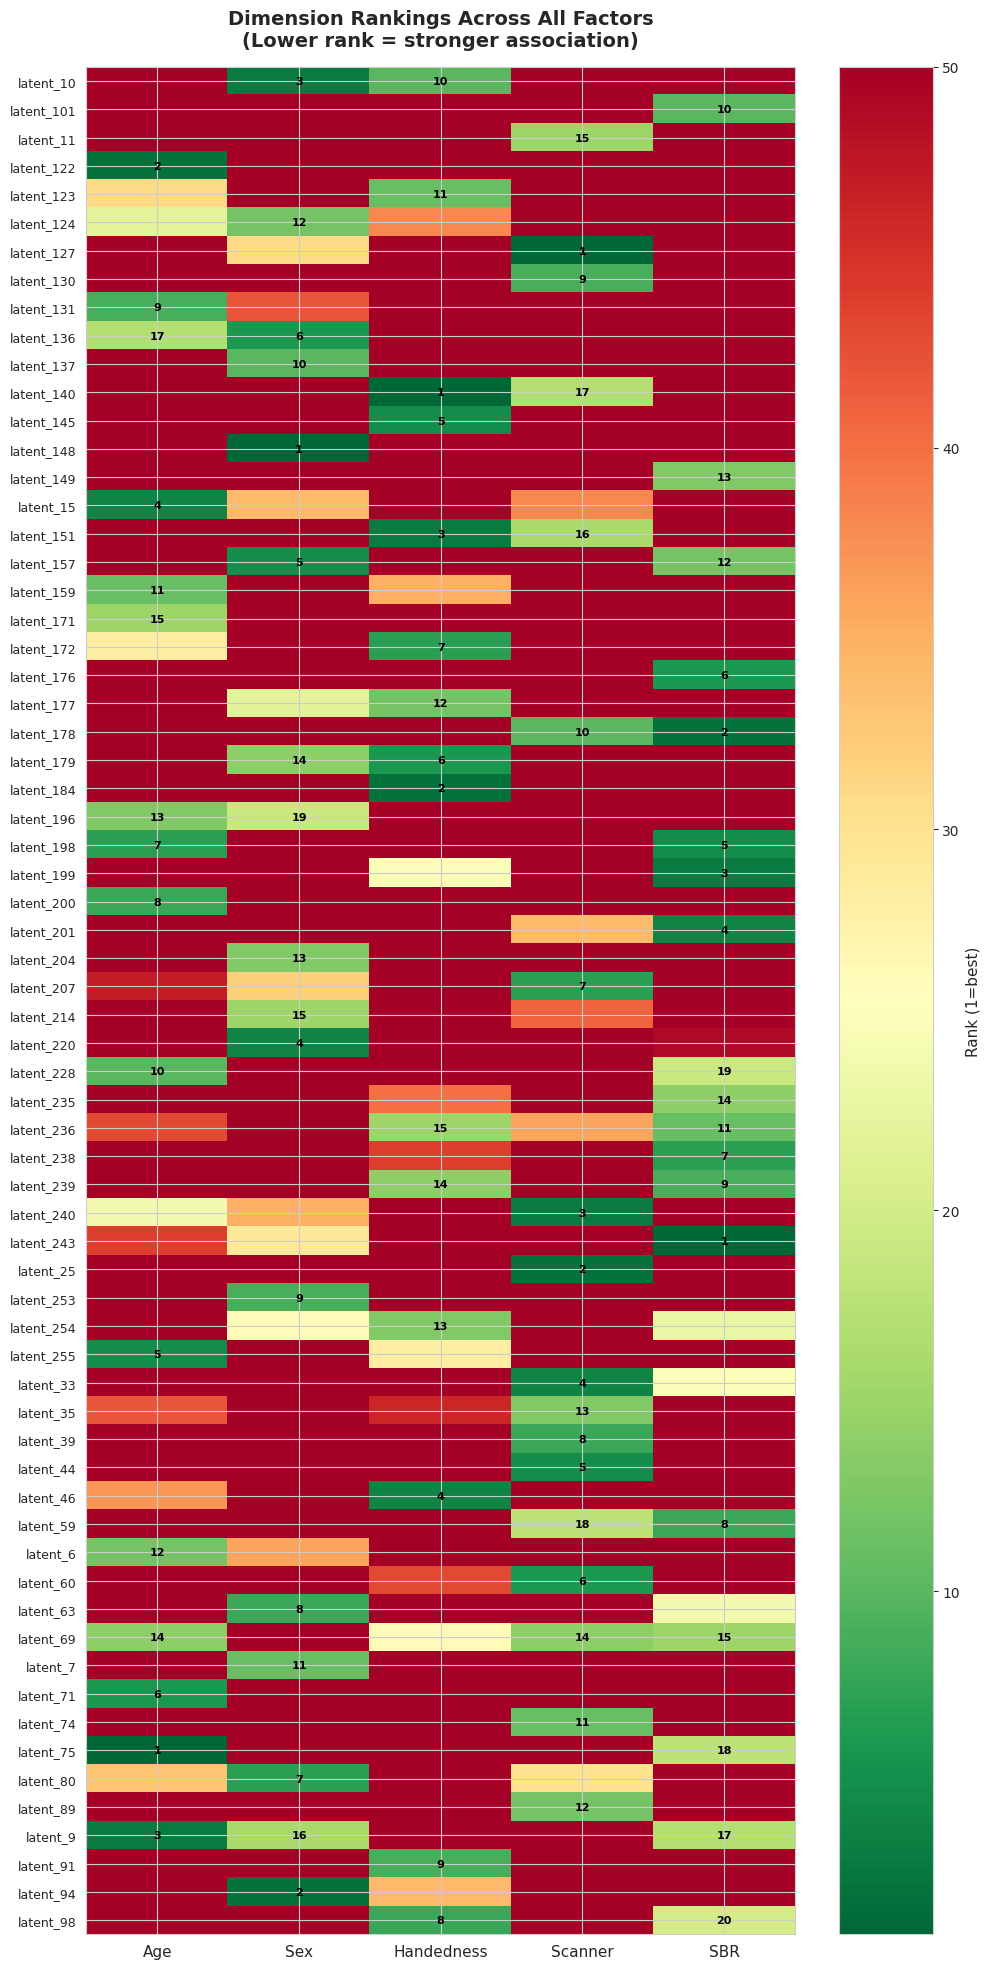

Plot saved to: output/dimension_factor_ranking_heatmap.png


In [17]:
# Create a matrix showing top dimensions for each factor
top_n_display = 15

# Collect all top dimensions
all_top_dims = set()
factor_rankings = {}

for factor_name, df_corr, sep, metric_col in plot_data:
    if df_corr is None:
        continue
    top_dims = df_corr.head(top_n_display)['Feature'].tolist()
    all_top_dims.update(top_dims)
    factor_rankings[factor_name] = {row['Feature']: row['Rank'] for _, row in df_corr.iterrows()}

all_top_dims = sorted(list(all_top_dims))

# Create ranking matrix
ranking_matrix = []
factor_names = [name for name, _, _, _ in plot_data if name in factor_rankings]

for dim in all_top_dims:
    row = []
    for factor_name in factor_names:
        rank = factor_rankings[factor_name].get(dim, 257)  # 257 if not in top rankings
        row.append(rank)
    ranking_matrix.append(row)

ranking_matrix = np.array(ranking_matrix)

# Create heatmap
fig, ax = plt.subplots(figsize=(10, max(8, len(all_top_dims) * 0.3)))

# Use reversed colormap so rank 1 is darkest
im = ax.imshow(ranking_matrix, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=50)

# Set ticks
ax.set_xticks(range(len(factor_names)))
ax.set_xticklabels(factor_names, fontsize=11)
ax.set_yticks(range(len(all_top_dims)))
ax.set_yticklabels(all_top_dims, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Rank (1=best)', fontsize=11)

# Add rank values to cells (only for top 20)
for i in range(len(all_top_dims)):
    for j in range(len(factor_names)):
        rank = ranking_matrix[i, j]
        if rank <= 20:
            text = ax.text(j, i, f'{int(rank)}',
                          ha="center", va="center", color="black", fontsize=8, fontweight='bold')

ax.set_title('Dimension Rankings Across All Factors\n(Lower rank = stronger association)', 
            fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('output/dimension_factor_ranking_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/dimension_factor_ranking_heatmap.png")

## Section 5: Save Results

### 5.1 Save Correlation Results

In [18]:
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Save individual correlation results
df_age_corr.to_csv(output_dir / 'dimension_correlations_age.csv', index=False)
df_sex_corr.to_csv(output_dir / 'dimension_correlations_sex.csv', index=False)
if df_hand_corr is not None:
    df_hand_corr.to_csv(output_dir / 'dimension_correlations_handedness.csv', index=False)
df_scanner_corr.to_csv(output_dir / 'dimension_correlations_scanner.csv', index=False)
df_sbr_corr.to_csv(output_dir / 'dimension_correlations_sbr.csv', index=False)

# Save summary
df_summary.to_csv(output_dir / 'dimension_factor_summary.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'dimension_correlations_age.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sex.csv'}")
if df_hand_corr is not None:
    print(f"  - {output_dir / 'dimension_correlations_handedness.csv'}")
print(f"  - {output_dir / 'dimension_correlations_scanner.csv'}")
print(f"  - {output_dir / 'dimension_correlations_sbr.csv'}")
print(f"  - {output_dir / 'dimension_factor_summary.csv'}")

Results saved to:
  - output/dimension_correlations_age.csv
  - output/dimension_correlations_sex.csv
  - output/dimension_correlations_handedness.csv
  - output/dimension_correlations_scanner.csv
  - output/dimension_correlations_sbr.csv
  - output/dimension_factor_summary.csv


### 5.2 Final Summary

In [19]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

print("\nKey Findings:")
print("-" * 80)

for _, row in df_summary.iterrows():
    quality = "EXCELLENT" if row['Gap_Percent'] > 20 else "GOOD" if row['Gap_Percent'] > 10 else "MODERATE" if row['Gap_Percent'] > 5 else "WEAK"
    
    print(f"\n{row['Factor']}:")
    print(f"  Top Dimension: {row['Top_Dimension']}")
    print(f"  {row['Metric']}: {row['Top_Value']:.4f}")
    print(f"  Separation: {quality} ({row['Gap_Percent']:.1f}% gap from 2nd-best)")
    print(f"  Statistical significance: p={row['P_Value']:.4e}")

print("\n" + "="*80)
print("All results and visualizations saved to output/ directory")
print("="*80)


ANALYSIS COMPLETE

Key Findings:
--------------------------------------------------------------------------------

Age:
  Top Dimension: latent_75
  Pearson r: 0.0579
  Separation: EXCELLENT (21.1% gap from 2nd-best)
  Statistical significance: p=4.8295e-03

Sex:
  Top Dimension: latent_148
  Point-biserial r: 0.0593
  Separation: WEAK (4.0% gap from 2nd-best)
  Statistical significance: p=3.9150e-03

Handedness:
  Top Dimension: latent_140
  Eta²: 0.0035
  Separation: WEAK (0.9% gap from 2nd-best)
  Statistical significance: p=1.5557e-02

Scanner:
  Top Dimension: latent_127
  Eta²: 0.0120
  Separation: WEAK (1.9% gap from 2nd-best)
  Statistical significance: p=1.9258e-02

SBR:
  Top Dimension: latent_243
  Pearson r: 0.0559
  Separation: WEAK (4.6% gap from 2nd-best)
  Statistical significance: p=6.4501e-03

All results and visualizations saved to output/ directory
